In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import os

# ── Shared style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e5e5e5",
    "grid.linewidth":    0.6,
    "axes.axisbelow":    True,
    "figure.dpi":        150,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
})

# Palette (mirrors dashboard)
C_AMBER   = "#BA7517"
C_BLUE    = "#185FA5"
C_GREEN   = "#3B6D11"
C_PURPLE  = "#7F77DD"
C_GRAY    = "#888780"
C_PINK    = "#D4537E"
C_TEAL    = "#1D9E75"
C_RED     = "#E24B4A"

OUTPUT_DIR = "charts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

YEARS = list(range(2015, 2025))

print("Imports & style loaded.")

Imports & style loaded.


In [10]:
DATA_DIR = "../labour/labour_report_all_csv"   # change this to the folder containing your CSVs

df_u_sector  = pd.read_csv(os.path.join(DATA_DIR, "Table_6_1_Underemployment_Rate_by_Major_Industry_Group.csv"))
df_u_gender  = pd.read_csv(os.path.join(DATA_DIR, "Table_6_2_Underemployment_Rate_by_Gender.csv"))
df_u_edu     = pd.read_csv(os.path.join(DATA_DIR, "Table_6_3_Underemployment_Rate_by_Level_of_Education_and_Gender.csv"))
df_u_dist    = pd.read_csv(os.path.join(DATA_DIR, "Table_6_4_Underemployment_Unemployment_Informal_Employment_by_District.csv"))
df_ea        = pd.read_csv(os.path.join(DATA_DIR, "Table_3.1_-_Economically_active_inactive_population_by_gender.csv"))
df_lfpr      = pd.read_csv(os.path.join(DATA_DIR, "Table_3.4_-_Labour_Force_participation_rates_by_age_groups_gender_and_sector.csv"))
df_un_gender = pd.read_csv(os.path.join(DATA_DIR, "Table_5.2_Unemployment_rates_by_gender.csv"))
df_informal  = pd.read_csv(os.path.join(DATA_DIR, "Distribution of Informal_Formal sector employment by gender.csv"))

print("All 8 files loaded.")
print(f"  df_u_sector  : {df_u_sector.shape}")
print(f"  df_u_gender  : {df_u_gender.shape}")
print(f"  df_u_edu     : {df_u_edu.shape}")
print(f"  df_u_dist    : {df_u_dist.shape}")
print(f"  df_ea        : {df_ea.shape}")
print(f"  df_lfpr      : {df_lfpr.shape}")
print(f"  df_un_gender : {df_un_gender.shape}")
print(f"  df_informal  : {df_informal.shape}")

All 8 files loaded.
  df_u_sector  : (40, 3)
  df_u_gender  : (33, 3)
  df_u_edu     : (50, 5)
  df_u_dist    : (270, 5)
  df_ea        : (30, 6)
  df_lfpr      : (295, 7)
  df_un_gender : (10, 4)
  df_informal  : (30, 8)


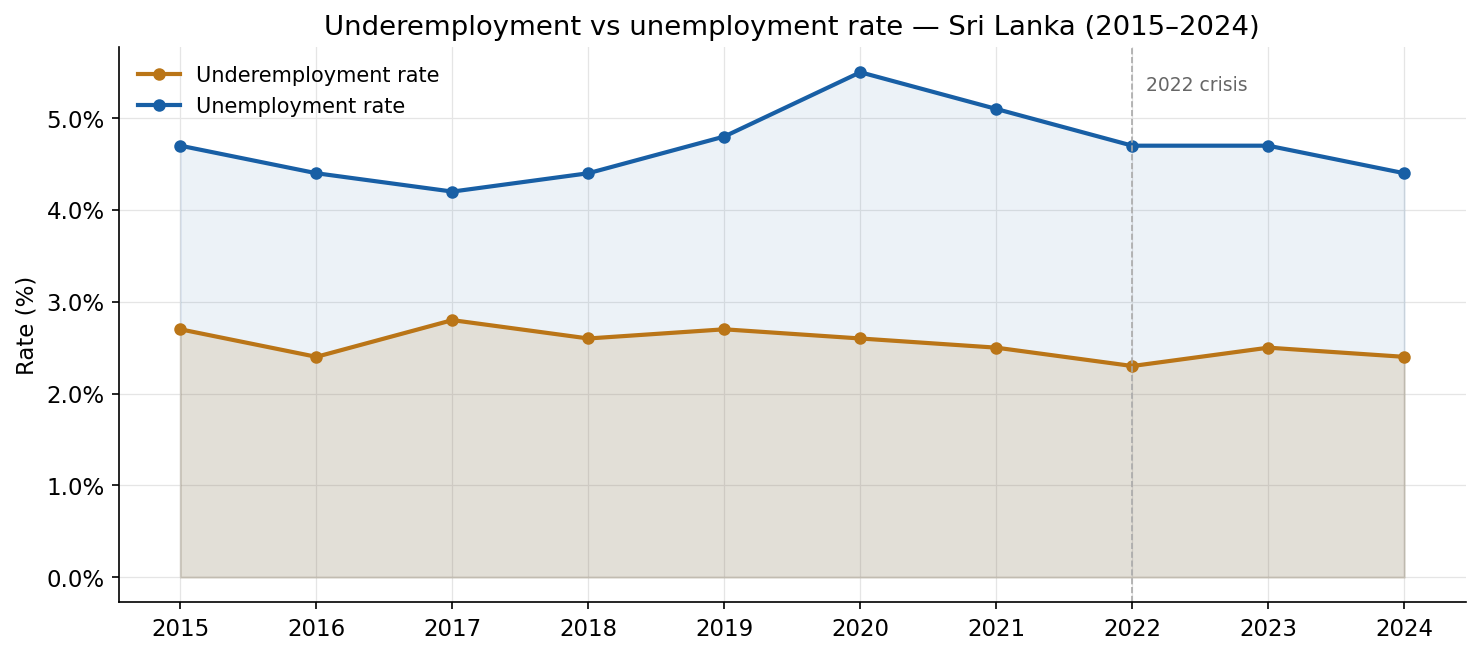

Saved → charts/chart1_under_vs_unemployment.png


In [8]:
# ── Prepare series ────────────────────────────────────────────────────────────
u_total  = df_u_gender[df_u_gender["Gender"] == "Total"].sort_values("Year")
un_total = df_un_gender.sort_values("Year")

# Filter to 2015–2024 only (df_u_gender has 2014 row too)
u_total  = u_total[u_total["Year"] >= 2015]

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.fill_between(u_total["Year"],  u_total["Underemployment_Rate_Percent"],
                alpha=0.15, color=C_AMBER)
ax.fill_between(un_total["Year"], un_total["Total"],
                alpha=0.08, color=C_BLUE)

ax.plot(u_total["Year"],  u_total["Underemployment_Rate_Percent"],
        marker="o", markersize=5, color=C_AMBER, linewidth=2,   label="Underemployment rate")
ax.plot(un_total["Year"], un_total["Total"],
        marker="o", markersize=5, color=C_BLUE,  linewidth=2,   label="Unemployment rate")

# Annotate 2022 crisis
ax.axvline(2022, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax.text(2022.1, 5.3, "2022 crisis", fontsize=9, color="#666666")

ax.set_xticks(YEARS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.set_ylabel("Rate (%)")
ax.set_title("Underemployment vs unemployment rate — Sri Lanka (2015–2024)", fontweight="500")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart1_under_vs_unemployment.png"))
plt.show()
print("Saved → charts/chart1_under_vs_unemployment.png")

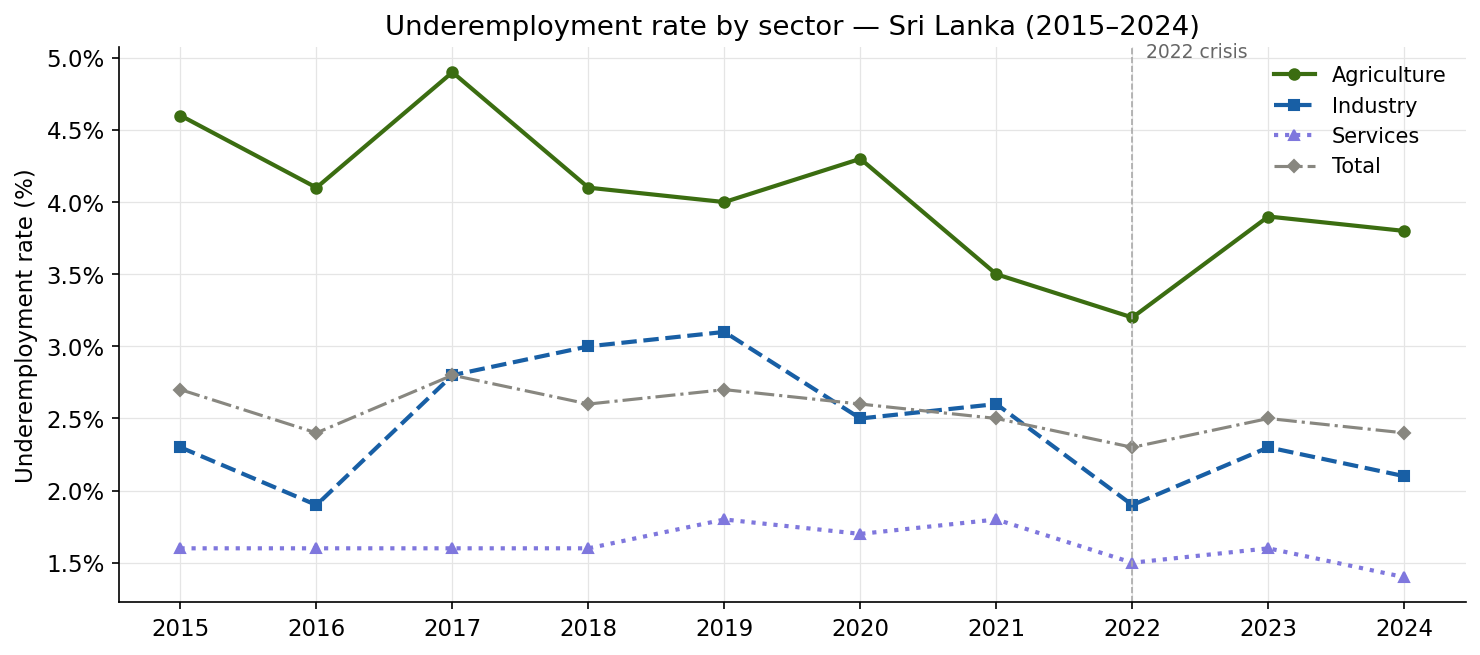

Saved → charts/chart2_sector.png


In [9]:
# ── Prepare series ────────────────────────────────────────────────────────────
def sector_series(sector):
    return (df_u_sector[df_u_sector["Major_Industry_Group"] == sector]
            .sort_values("Year")["Underemployment_Rate_Percent"].values)

agri = sector_series("Agriculture")
ind  = sector_series("Industry")
svc  = sector_series("Services")
tot  = sector_series("Total")

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(YEARS, agri, marker="o", markersize=5, color=C_GREEN,  linewidth=2,   label="Agriculture")
ax.plot(YEARS, ind,  marker="s", markersize=5, color=C_BLUE,   linewidth=2,   label="Industry",    linestyle="--")
ax.plot(YEARS, svc,  marker="^", markersize=5, color=C_PURPLE, linewidth=2,   label="Services",    linestyle=":")
ax.plot(YEARS, tot,  marker="D", markersize=4, color=C_GRAY,   linewidth=1.5, label="Total",       linestyle="-.")

ax.axvline(2022, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax.text(2022.1, 5.0, "2022 crisis", fontsize=9, color="#666666")

ax.set_xticks(YEARS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.set_ylabel("Underemployment rate (%)")
ax.set_title("Underemployment rate by sector — Sri Lanka (2015–2024)", fontweight="500")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart2_sector.png"))
plt.show()
print("Saved → charts/chart2_sector.png")

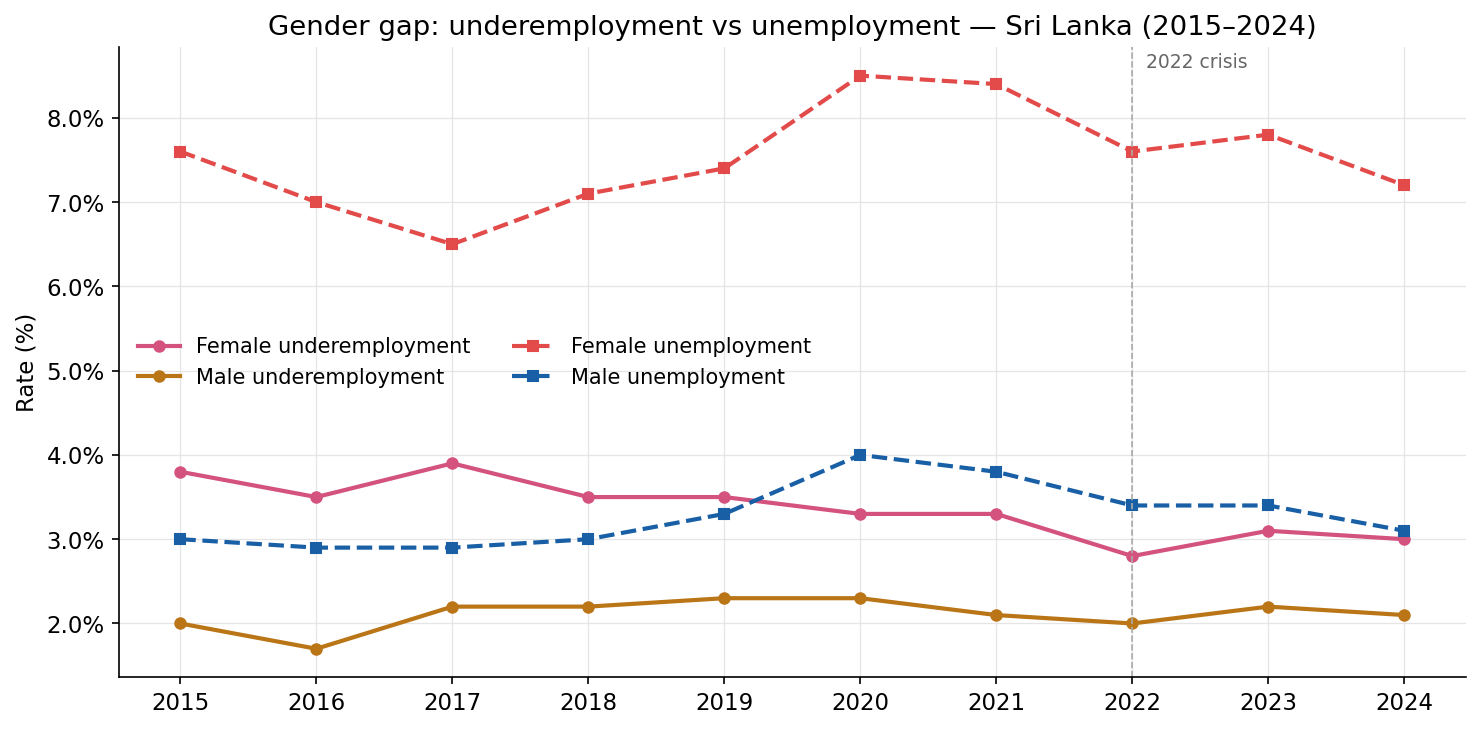

Saved → charts/chart3_gender_gap.png


In [11]:
# ── Prepare series ────────────────────────────────────────────────────────────
def u_gender_series(gender):
    return (df_u_gender[(df_u_gender["Gender"] == gender) & (df_u_gender["Year"] >= 2015)]
            .sort_values("Year")["Underemployment_Rate_Percent"].values)

u_male   = u_gender_series("Male")
u_female = u_gender_series("Female")
un_male  = df_un_gender.sort_values("Year")["Male"].values
un_fem   = df_un_gender.sort_values("Year")["Female"].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(YEARS, u_female, marker="o", markersize=5, color=C_PINK,  linewidth=2,   label="Female underemployment")
ax.plot(YEARS, u_male,   marker="o", markersize=5, color=C_AMBER, linewidth=2,   label="Male underemployment")
ax.plot(YEARS, un_fem,   marker="s", markersize=5, color=C_RED,   linewidth=2,   label="Female unemployment",   linestyle="--")
ax.plot(YEARS, un_male,  marker="s", markersize=5, color=C_BLUE,  linewidth=2,   label="Male unemployment",     linestyle="--")

ax.axvline(2022, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax.text(2022.1, 8.6, "2022 crisis", fontsize=9, color="#666666")

ax.set_xticks(YEARS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.set_ylabel("Rate (%)")
ax.set_title("Gender gap: underemployment vs unemployment — Sri Lanka (2015–2024)", fontweight="500")
ax.legend(frameon=False, fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart3_gender_gap.png"))
plt.show()
print("Saved → charts/chart3_gender_gap.png")

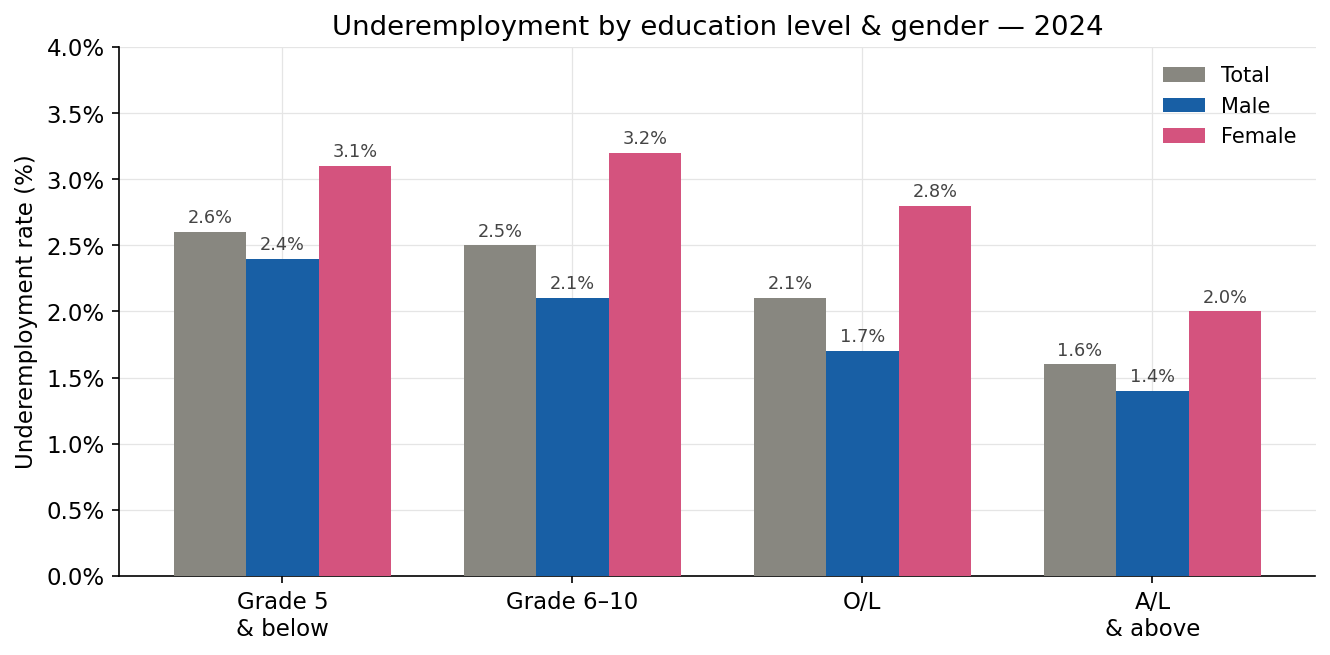

Saved → charts/chart4_education_gender.png


In [12]:
# ── Prepare 2024 slice ────────────────────────────────────────────────────────
edu_2024 = df_u_edu[df_u_edu["Year"] == 2024].copy()

edu_order = ["Grade 5 and below", "Grade 6-10", "G.C.E.(O/L)", "G.C.E.(A/L) & above"]
edu_labels_short = ["Grade 5\n& below", "Grade 6–10", "O/L", "A/L\n& above"]

edu_2024 = edu_2024[edu_2024["Level_of_Education"].isin(edu_order)]
edu_2024["Level_of_Education"] = pd.Categorical(edu_2024["Level_of_Education"], categories=edu_order, ordered=True)
edu_2024 = edu_2024.sort_values("Level_of_Education")

x = np.arange(len(edu_order))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))

bars_t = ax.bar(x - width, edu_2024["Total_Rate"],  width, color=C_GRAY,  label="Total",  zorder=3)
bars_m = ax.bar(x,          edu_2024["Male_Rate"],   width, color=C_BLUE,  label="Male",   zorder=3)
bars_f = ax.bar(x + width,  edu_2024["Female_Rate"], width, color=C_PINK,  label="Female", zorder=3)

for bars in [bars_t, bars_m, bars_f]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.04, f"{h:.1f}%",
                ha="center", va="bottom", fontsize=8.5, color="#444444")

ax.set_xticks(x)
ax.set_xticklabels(edu_labels_short)
ax.set_ylim(0, 4.0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.set_ylabel("Underemployment rate (%)")
ax.set_title("Underemployment by education level & gender — 2024", fontweight="500")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart4_education_gender.png"))
plt.show()
print("Saved → charts/chart4_education_gender.png")

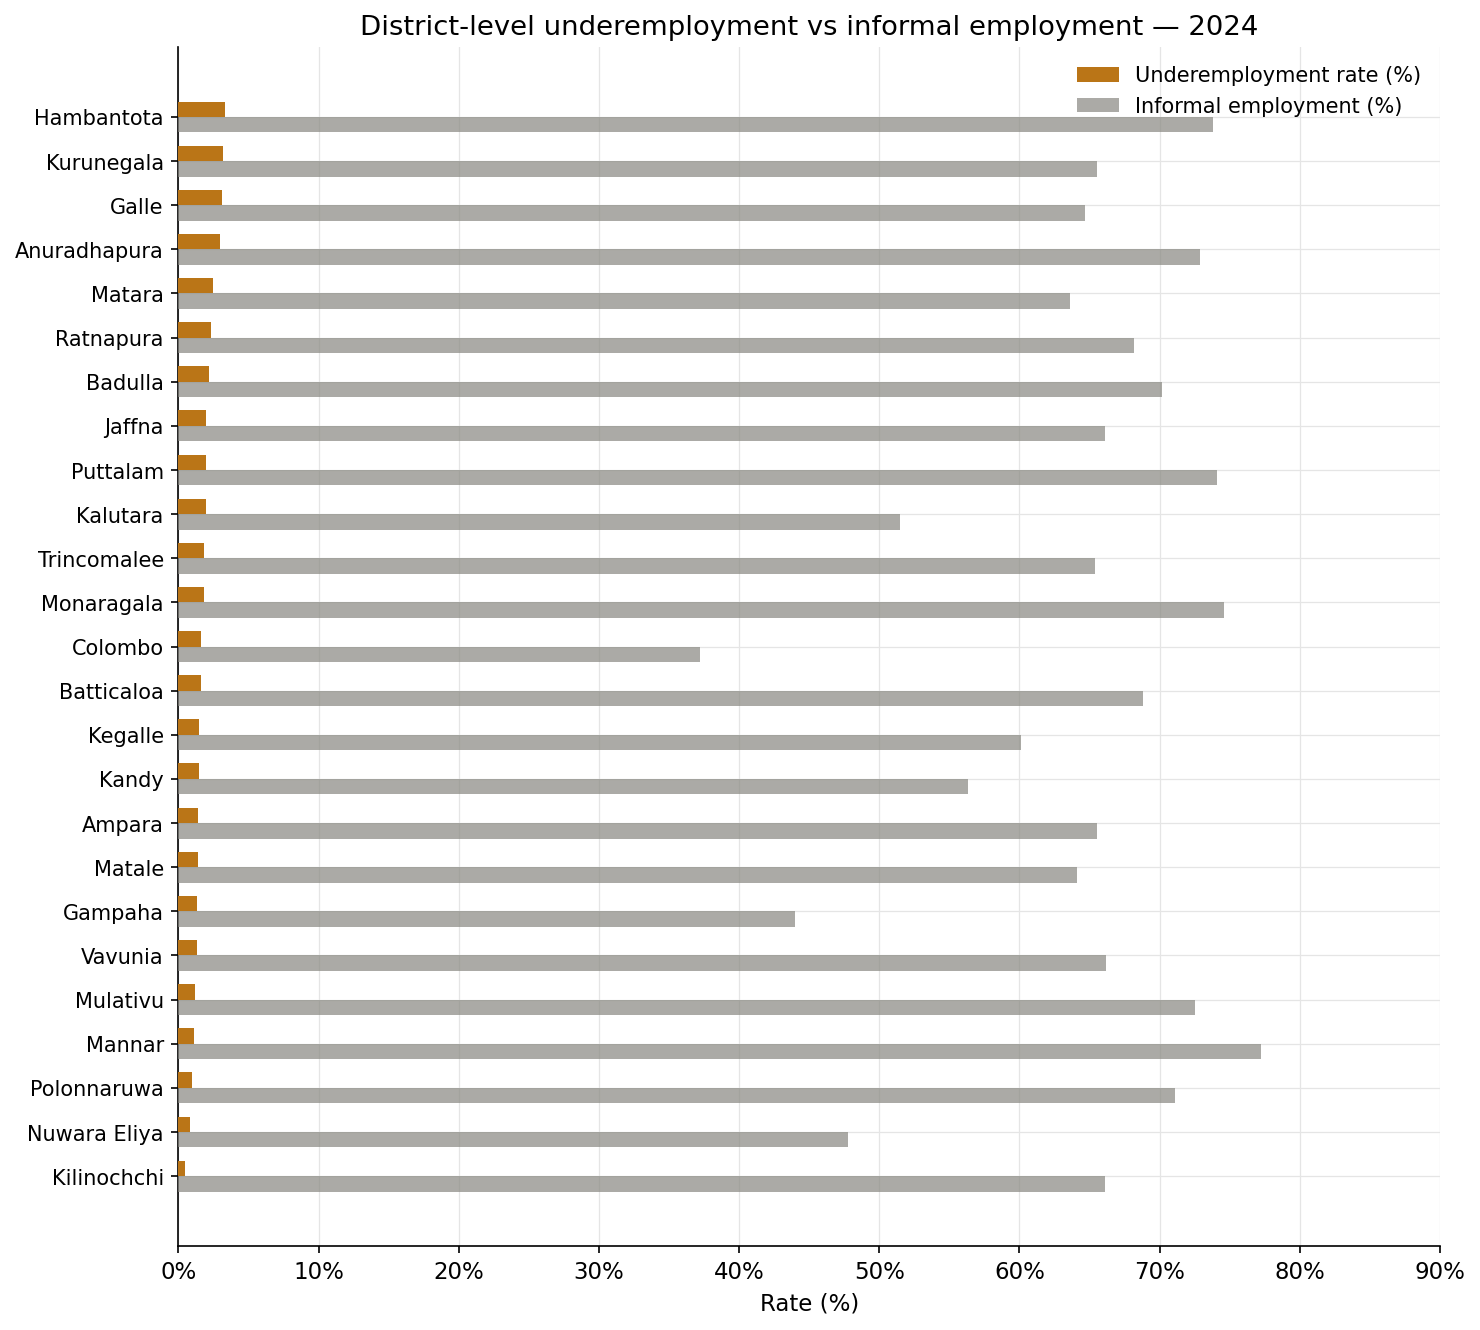

Saved → charts/chart5_district.png


In [13]:
# ── Prepare 2024 district slice ───────────────────────────────────────────────
dist_2024 = (df_u_dist[(df_u_dist["Year"] == 2024) & (df_u_dist["District"] != "All Island")]
             .dropna(subset=["Underemployment_Rate", "Percentage_of_Informal_Employment"])
             .copy())

dist_2024 = dist_2024.sort_values("Underemployment_Rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

y = np.arange(len(dist_2024))
height = 0.35

ax.barh(y + height / 2, dist_2024["Underemployment_Rate"],
        height, color=C_AMBER, label="Underemployment rate (%)", zorder=3)
ax.barh(y - height / 2, dist_2024["Percentage_of_Informal_Employment"],
        height, color=C_GRAY,  alpha=0.7, label="Informal employment (%)", zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(dist_2024["District"], fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_xlabel("Rate (%)")
ax.set_title("District-level underemployment vs informal employment — 2024", fontweight="500")
ax.legend(frameon=False, fontsize=10)
ax.set_xlim(0, 90)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart5_district.png"))
plt.show()
print("Saved → charts/chart5_district.png")

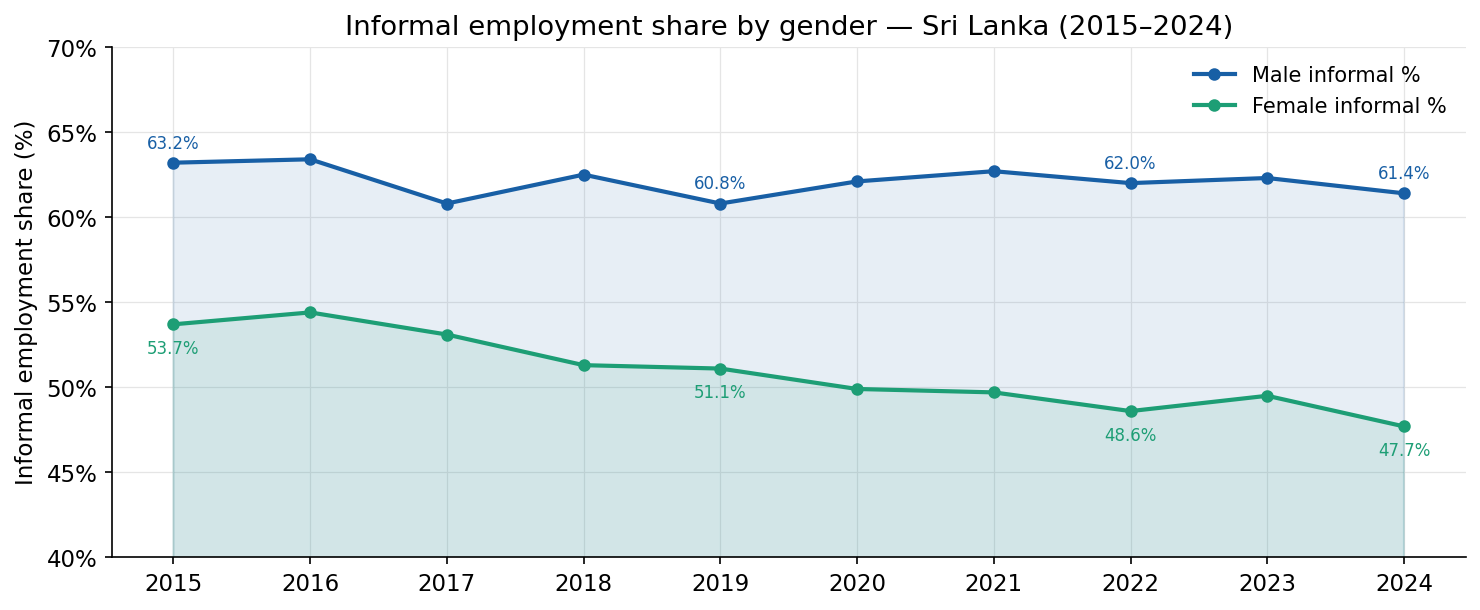

Saved → charts/chart6_informal_gender.png


In [14]:
# ── Prepare series ────────────────────────────────────────────────────────────
inf_male = (df_informal[df_informal["Gender"] == "Male"]
            .sort_values("Year")["Informal_Pct"].values)
inf_fem  = (df_informal[df_informal["Gender"] == "Female"]
            .sort_values("Year")["Informal_Pct"].values)

fig, ax = plt.subplots(figsize=(10, 4.2))

ax.fill_between(YEARS, inf_male, alpha=0.10, color=C_BLUE)
ax.fill_between(YEARS, inf_fem,  alpha=0.10, color=C_TEAL)

ax.plot(YEARS, inf_male, marker="o", markersize=5, color=C_BLUE,  linewidth=2, label="Male informal %")
ax.plot(YEARS, inf_fem,  marker="o", markersize=5, color=C_TEAL,  linewidth=2, label="Female informal %")

for yr, m, f in zip(YEARS, inf_male, inf_fem):
    if yr in [2015, 2019, 2022, 2024]:
        ax.annotate(f"{m:.1f}%", (yr, m), textcoords="offset points",
                    xytext=(0, 7), ha="center", fontsize=8, color=C_BLUE)
        ax.annotate(f"{f:.1f}%", (yr, f), textcoords="offset points",
                    xytext=(0, -14), ha="center", fontsize=8, color=C_TEAL)

ax.set_xticks(YEARS)
ax.set_ylim(40, 70)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylabel("Informal employment share (%)")
ax.set_title("Informal employment share by gender — Sri Lanka (2015–2024)", fontweight="500")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart6_informal_gender.png"))
plt.show()
print("Saved → charts/chart6_informal_gender.png")

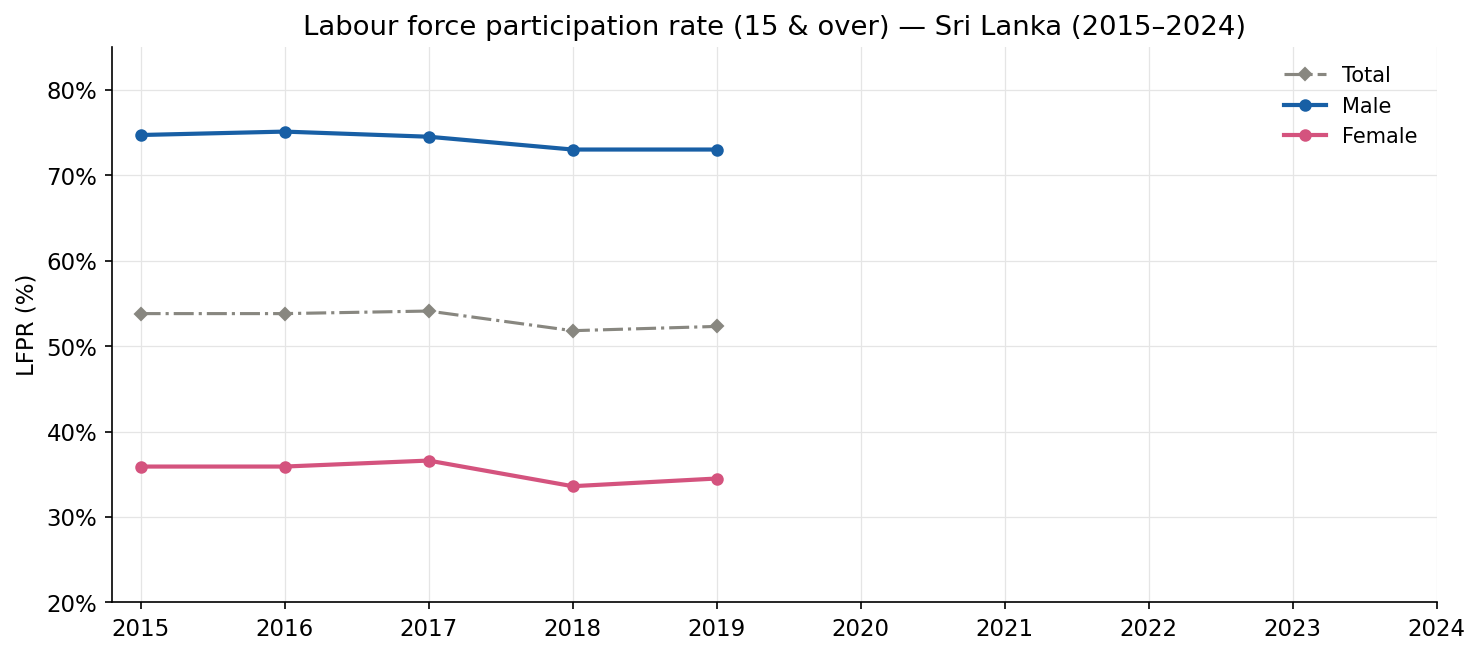

Saved → charts/chart7_lfpr.png


In [15]:
# ── Extract "15 & over" standardised LFPR rows ───────────────────────────────
lfpr_rows = df_lfpr[
    (df_lfpr["Age_Group"].str.strip() == "15 & over") |
    (df_lfpr["Sector_or_Category"].str.strip() == "Overall")
].copy()

# For 2015–2019 the column name is Age_Group; for 2020+ it uses Category/Sector structure
# Easier: pivot from the known Total/Male/Female columns directly
lfpr_overall = (df_lfpr[
    (df_lfpr["Age_Group"].fillna("").str.strip().isin(["15 & over", ""])) &
    (df_lfpr["Sector_or_Category"].fillna("").str.strip().isin(["Total", "Overall", ""]))
].copy())

# Keep one row per year (the overall 15+ rate)
lfpr_yr = []
for yr in YEARS:
    sub = lfpr_overall[lfpr_overall["Year"] == yr]
    if len(sub) == 0:
        # fallback: row where Age_Group == "15 & over"
        sub = df_lfpr[(df_lfpr["Year"] == yr) &
                      (df_lfpr["Age_Group"].fillna("").str.strip() == "15 & over")]
    if len(sub) > 0:
        row = sub.iloc[0]
        lfpr_yr.append({"Year": yr,
                        "Total": row["Total_(%)"],
                        "Male":  row["Male_(%)"],
                        "Female":row["Female_(%)"]})

lfpr_df = pd.DataFrame(lfpr_yr)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(lfpr_df["Year"], lfpr_df["Total"],  marker="D", markersize=4,
        color=C_GRAY,  linewidth=1.5, linestyle="-.", label="Total")
ax.plot(lfpr_df["Year"], lfpr_df["Male"],   marker="o", markersize=5,
        color=C_BLUE,  linewidth=2,           label="Male")
ax.plot(lfpr_df["Year"], lfpr_df["Female"], marker="o", markersize=5,
        color=C_PINK,  linewidth=2,           label="Female")

ax.set_xticks(YEARS)
ax.set_ylim(20, 85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylabel("LFPR (%)")
ax.set_title("Labour force participation rate (15 & over) — Sri Lanka (2015–2024)", fontweight="500")
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart7_lfpr.png"))
plt.show()
print("Saved → charts/chart7_lfpr.png")

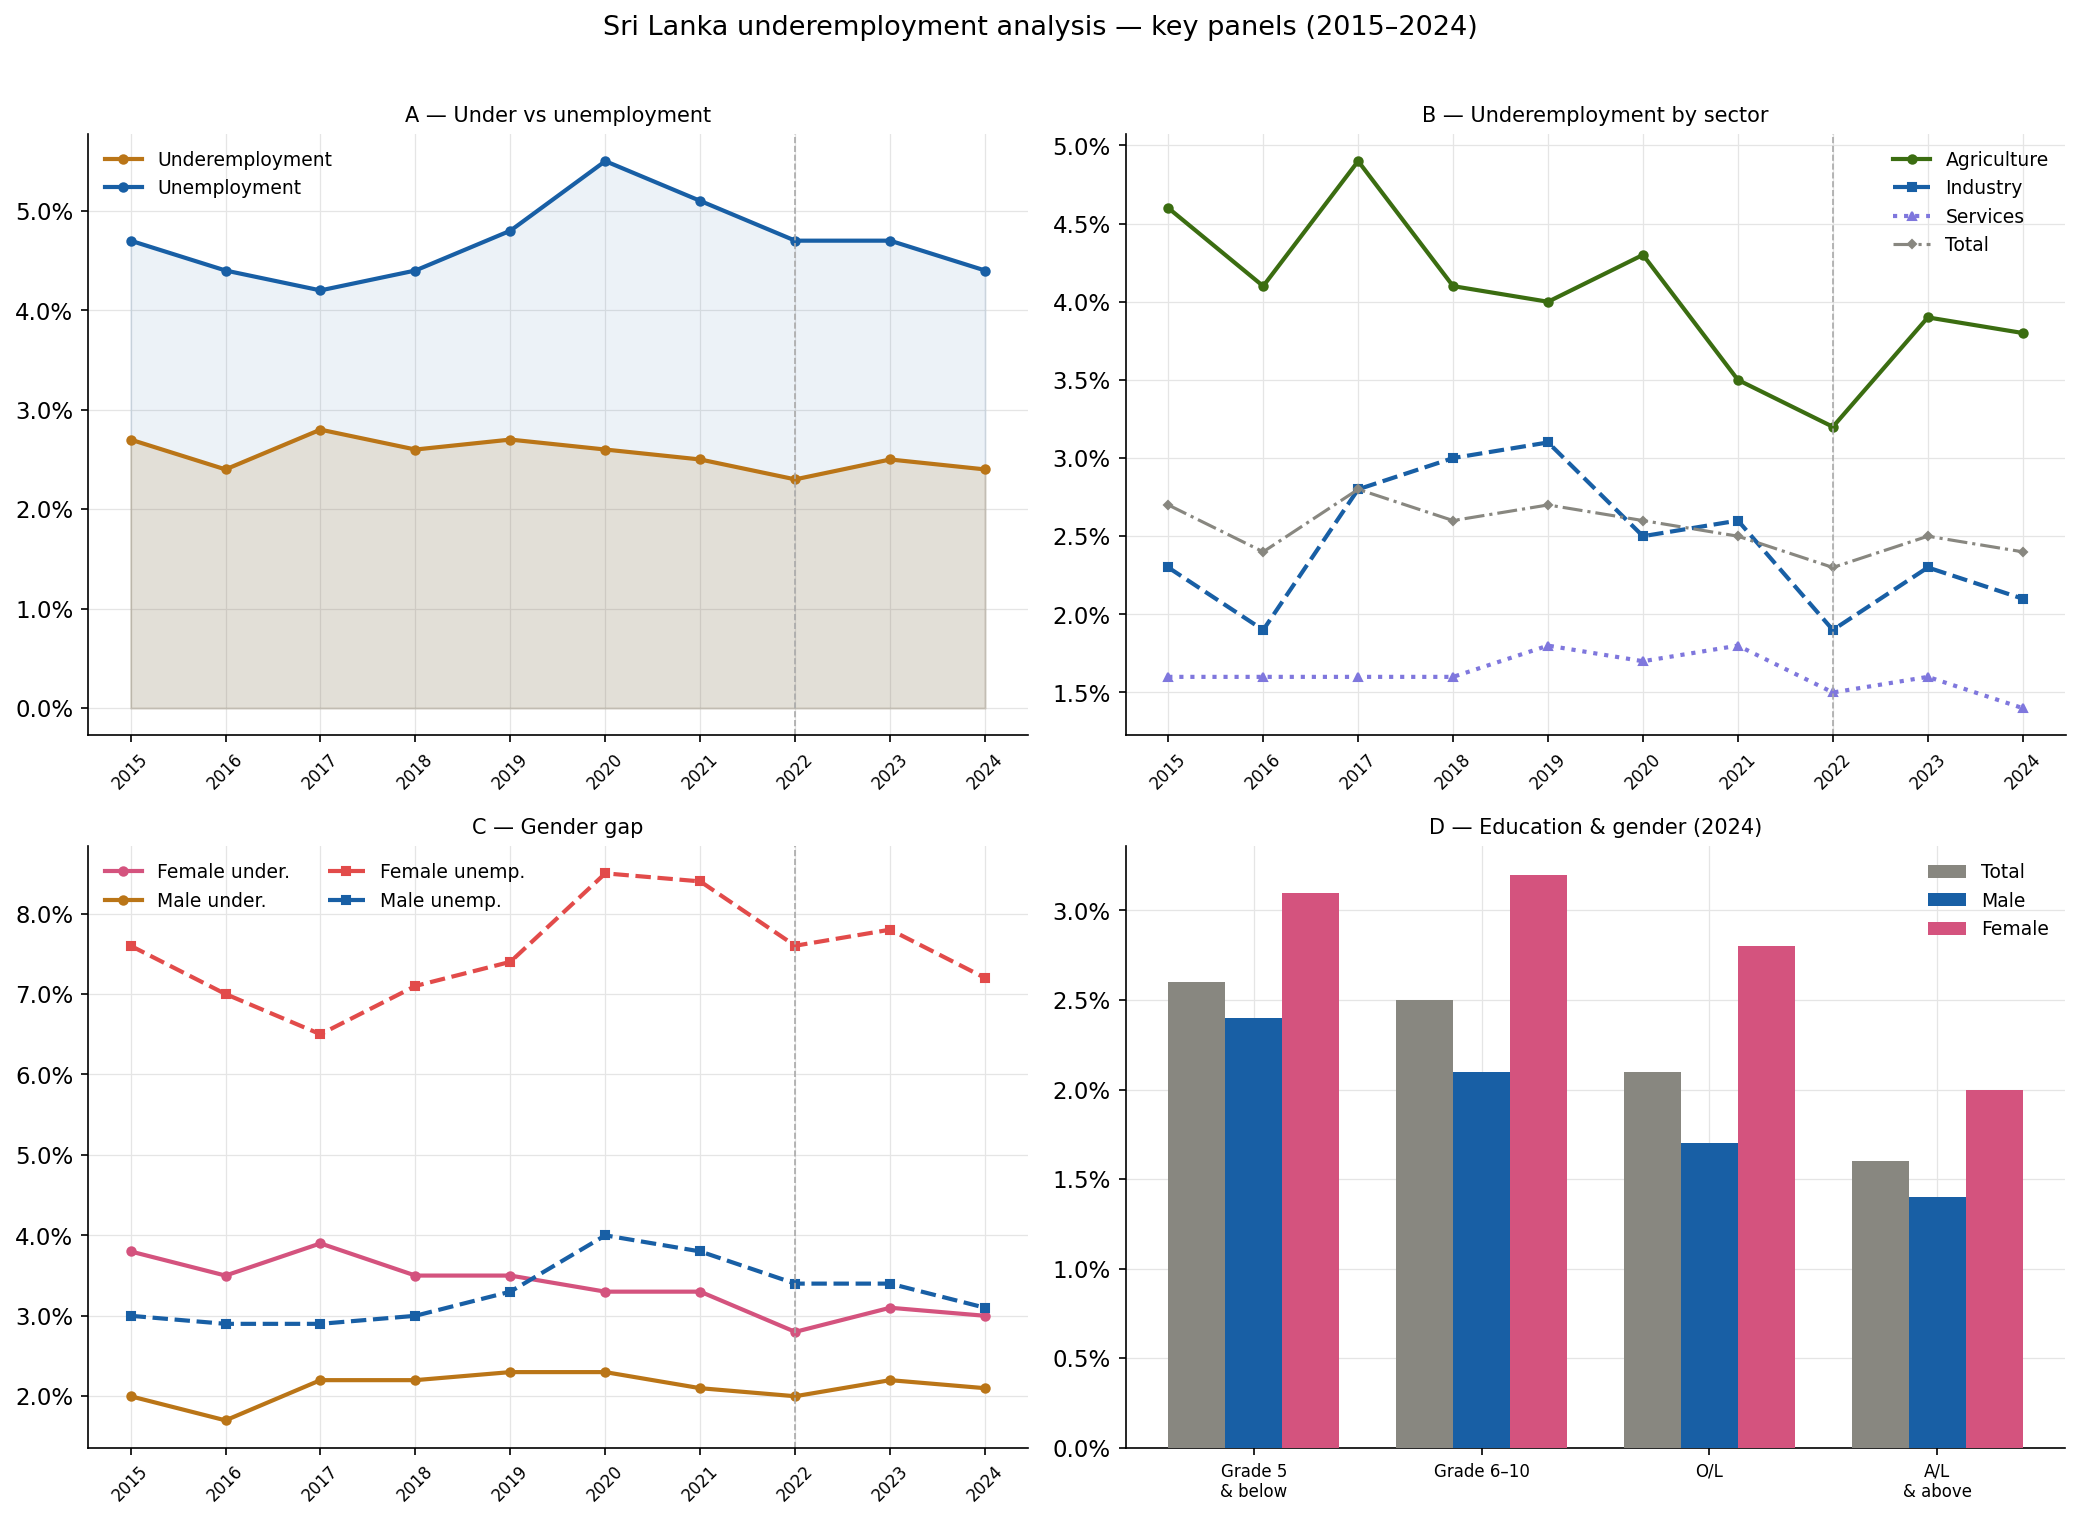

Saved → charts/chart9_summary_panel.png


In [16]:
# Combines charts 1, 2, 3, 4 into a 2×2 panel for papers/presentations.

# %%
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sri Lanka underemployment analysis — key panels (2015–2024)",
             fontsize=13, fontweight="500", y=1.01)

# ── Panel A: Under vs Un ──────────────────────────────────────────────────────
ax = axes[0, 0]
u_t = df_u_gender[(df_u_gender["Gender"] == "Total") & (df_u_gender["Year"] >= 2015)].sort_values("Year")
un_t = df_un_gender.sort_values("Year")
ax.fill_between(u_t["Year"],  u_t["Underemployment_Rate_Percent"],  alpha=0.15, color=C_AMBER)
ax.fill_between(un_t["Year"], un_t["Total"], alpha=0.08, color=C_BLUE)
ax.plot(u_t["Year"],  u_t["Underemployment_Rate_Percent"],  marker="o", markersize=4, color=C_AMBER, linewidth=2, label="Underemployment")
ax.plot(un_t["Year"], un_t["Total"], marker="o", markersize=4, color=C_BLUE,  linewidth=2, label="Unemployment")
ax.axvline(2022, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax.set_xticks(YEARS); ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.set_title("A — Under vs unemployment", fontweight="500", fontsize=10)
ax.legend(frameon=False, fontsize=9)

# ── Panel B: Sector ───────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(YEARS, agri, marker="o", markersize=4, color=C_GREEN,  linewidth=2, label="Agriculture")
ax.plot(YEARS, ind,  marker="s", markersize=4, color=C_BLUE,   linewidth=2, label="Industry",  linestyle="--")
ax.plot(YEARS, svc,  marker="^", markersize=4, color=C_PURPLE, linewidth=2, label="Services",  linestyle=":")
ax.plot(YEARS, tot,  marker="D", markersize=3, color=C_GRAY,   linewidth=1.5, label="Total",   linestyle="-.")
ax.axvline(2022, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax.set_xticks(YEARS); ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.set_title("B — Underemployment by sector", fontweight="500", fontsize=10)
ax.legend(frameon=False, fontsize=9)

# ── Panel C: Gender gap ───────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(YEARS, u_female, marker="o", markersize=4, color=C_PINK,  linewidth=2, label="Female under.")
ax.plot(YEARS, u_male,   marker="o", markersize=4, color=C_AMBER, linewidth=2, label="Male under.")
ax.plot(YEARS, un_fem,   marker="s", markersize=4, color=C_RED,   linewidth=2, label="Female unemp.", linestyle="--")
ax.plot(YEARS, un_male,  marker="s", markersize=4, color=C_BLUE,  linewidth=2, label="Male unemp.",   linestyle="--")
ax.axvline(2022, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax.set_xticks(YEARS); ax.tick_params(axis='x', labelrotation=45, labelsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.set_title("C — Gender gap", fontweight="500", fontsize=10)
ax.legend(frameon=False, fontsize=9, ncol=2)

# ── Panel D: Education (2024) ─────────────────────────────────────────────────
ax = axes[1, 1]
x = np.arange(len(edu_order))
width = 0.25
ax.bar(x - width, edu_2024["Total_Rate"],  width, color=C_GRAY,  label="Total",  zorder=3)
ax.bar(x,          edu_2024["Male_Rate"],   width, color=C_BLUE,  label="Male",   zorder=3)
ax.bar(x + width,  edu_2024["Female_Rate"], width, color=C_PINK,  label="Female", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(edu_labels_short, fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}%"))
ax.set_title("D — Education & gender (2024)", fontweight="500", fontsize=10)
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "chart9_summary_panel.png"))
plt.show()
print("Saved → charts/chart9_summary_panel.png")